In [23]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [6]:
df = pd.read_csv("Mall_Customers.csv")

In [7]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income (k$)'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

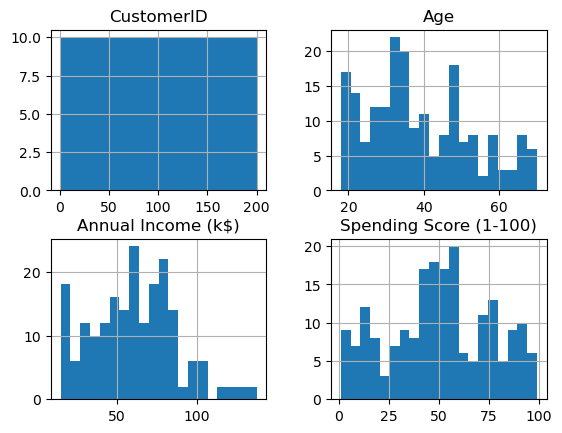

In [10]:
df.hist(bins=20 , grid=True)

In [11]:
data = df.copy()

In [12]:
data= data.drop("CustomerID" , axis = 1)

Text(0, 0.5, 'Annual Income in $')

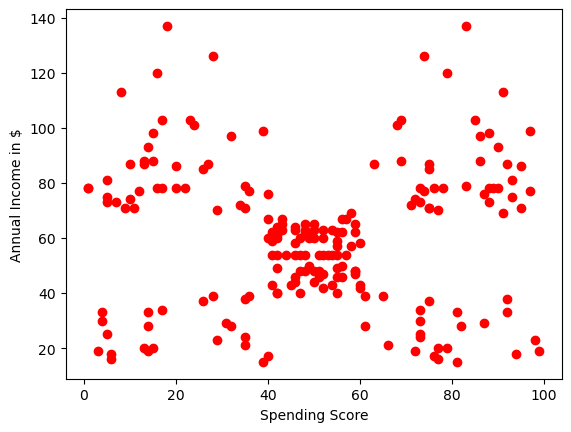

In [13]:
plt.scatter(x=df['Spending Score (1-100)'] , y=df['Annual Income (k$)'], color='red')
plt.xlabel("Spending Score")
plt.ylabel("Annual Income in $")

C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


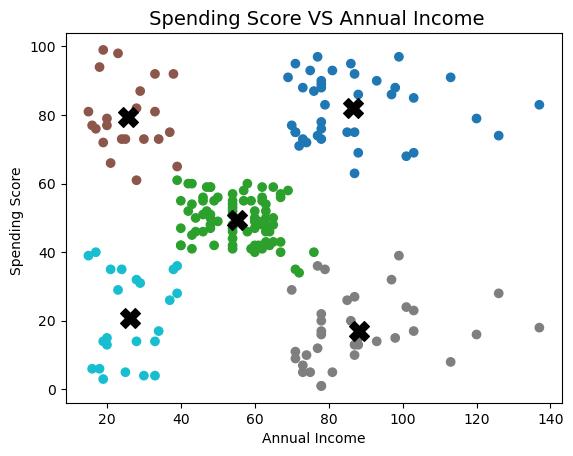

In [35]:
x =  df[['Annual Income (k$)', 'Spending Score (1-100)']]

Kmeans_cluster = KMeans(n_clusters = 5)
clusters = Kmeans_cluster.fit_predict(x)

plt.scatter(x['Annual Income (k$)'],
            x['Spending Score (1-100)'],
            cmap = "tab10",
            c =clusters,
           )


plt.title(" Spending Score VS Annual Income", fontsize=14)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score ")

centers = Kmeans_cluster.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    c='black',
    marker='X'
)


C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,24.000000,25.521739,26.304348,78.565217
1,86.265823,43.088608,55.291139,49.569620
2,163.500000,40.666667,87.750000,17.583333
3,162.000000,32.692308,86.538462,82.128205
4,23.000000,45.217391,26.304348,20.913043


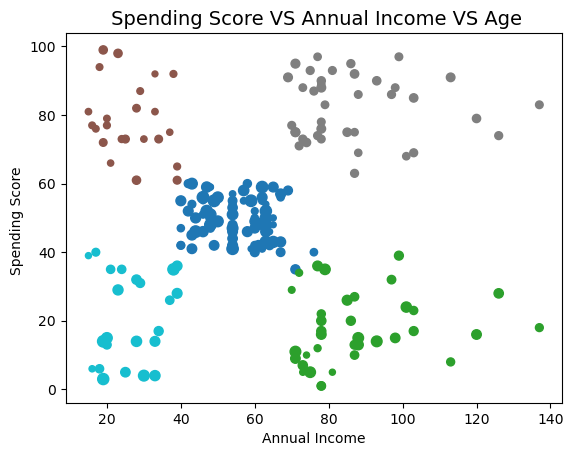

In [38]:
#Using age we can see that how age affects the cluster of annual income and spending score

x =  df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]

Kmeans_cluster = KMeans(n_clusters = 5)
clusters = Kmeans_cluster.fit_predict(x)

plt.scatter(x['Annual Income (k$)'],
            x['Spending Score (1-100)'],
            x["Age"],
            cmap = "tab10",
            c =clusters)

plt.title(" Spending Score VS Annual Income VS Age", fontsize=14)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score ")


df.groupby('Cluster').mean(numeric_only=True)


C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Wind

[269981.28, 183499.07470288628, 106348.37306211118, 73679.78903948836, 44448.45544793371, 37271.8862365895, 30273.394312070042, 24986.52564064288, 21900.341350107527, 19721.547527312745]


Text(0, 0.5, 'Wcss')

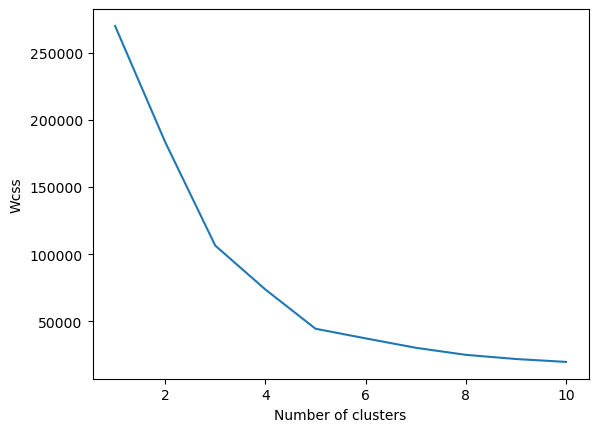

In [22]:
wcss=[]
for i in range(1,11):
    kmeans= KMeans(n_clusters = i)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    
print(wcss)
plt.plot(range(1,11),wcss)
plt.xlabel("Number of clusters")
plt.ylabel("Wcss")

In [ ]:
df.Age

Text(0.5, 0, 'Annual Income')

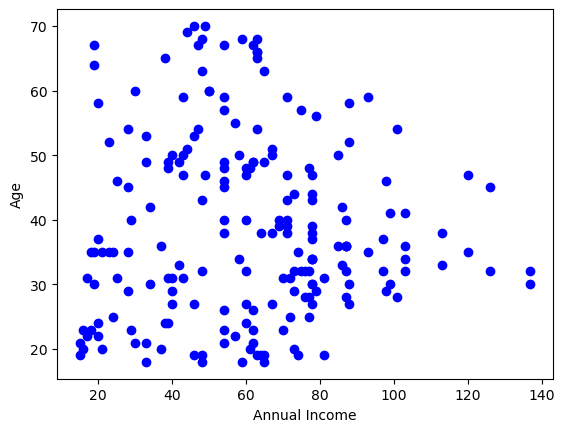

In [21]:
plt.scatter(x=df["Spending Score (1-100)"], y=df["Age"] , color="blue")
plt.ylabel("Age")
plt.xlabel("Annual Income")

C:\Users\HARSHVARDHAN\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


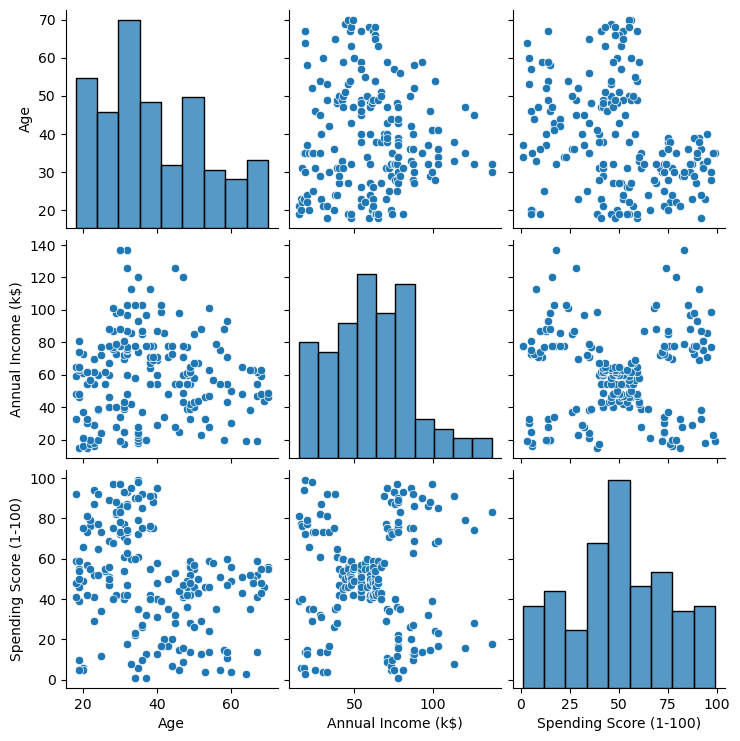

In [24]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])



In [ ]:
# “Customers were segmented into 5 clusters based on Age, Annual Income, and Spending Score. The model identified distinct groups such as high-value customers, low-value customers, and average consumers, which can help businesses in targeted marketing.”